# C — Visualization Pack

This notebook generates all 12 required visualization figures for the hackathon.

Every figure:
- is generated programmatically;
- is saved under `figures/`;
- uses the exact required filename;
- is saved at 150 DPI;
- includes a title and labeled axes;
- uses consistent styling;
- has a one-line takeaway recorded in `figures/figure_captions.md`.

Required figures:

1. fig01_missingness.png
2. fig02_before_after_cleaning.png
3. fig03_yield_distribution.png
4. fig04_region_crop_heatmap.png
5. fig05_correlation_heatmap.png
6. fig06_climate_by_region.png
7. fig07_yield_vs_season_temp.png
8. fig08_price_trends.png
9. fig09_revenue_by_crop_region.png
10. fig10_model_comparison.png
11. fig11_predicted_vs_actual_residuals.png
12. fig12_feature_importance.png

## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import FuncFormatter

sns.set_theme(
    style="whitegrid",
    context="talk"
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 150

## Paths

In [2]:
PROJECT_ROOT = Path("..")

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = PROCESSED_DIR / "master_train.csv"

print("Project root:", PROJECT_ROOT.resolve())
print("Figures directory:", FIGURES_DIR.resolve())

Project root: C:\Users\Administrator\Desktop\team_adwa
Figures directory: C:\Users\Administrator\Desktop\team_adwa\figures


## Load processed master data

In [3]:
df = pd.read_csv(TRAIN_PATH)

print("Master train shape:", df.shape)

display(df.head())

Master train shape: (15090, 27)


,plot_id,region,crop_type,survey_year,planting_month,altitude_m,rainfall_mm_season,farm_size_ha,fertilizer_kg_per_ha,improved_seed_used,...,season_temp_std_c,season_temp_deviation_c,weather_months_available,weather_months_expected,weather_months_missing,planting_month_num,fertilizer_improved_seed_interaction,rainfall_per_fertilizer,price_birr_per_quintal,yield_tons_per_ha
0,PLOT-000339,Oromia,barley,2024.0,Aug,2697.817349,1157.403560,0.867604,29.393684,0.0,...,1.960159,-1.030858,3,4,1,8,0.000000,6.774434,4590.0,2.209711
1,PLOT-007457,Amhara,maize,2023.0,Jun,1523.350141,897.420122,1.099197,16.843992,1.0,...,1.096459,-1.293787,3,4,1,6,16.843992,31.153343,4230.0,3.363254
2,PLOT-006092,Oromia,wheat,2024.0,Feb,2389.441948,1119.155741,0.811309,41.015144,0.0,...,0.951315,0.302476,4,4,0,2,0.000000,7.018898,5387.0,3.560614
3,PLOT-004128,SNNPR,barley,2022.0,Aug,2612.483420,1246.462210,1.602312,14.353759,0.0,...,1.294942,-0.697975,4,4,0,8,0.000000,25.941530,4181.0,1.924800
4,PLOT-003033,Amhara,sorghum,2021.0,Jul,1210.095040,928.477088,0.937758,33.736138,1.0,...,1.481741,-0.327120,3,4,1,7,33.736138,16.800947,2706.0,4.171220


## Load raw datasets for Figure 1

In [4]:
plot_raw_path = RAW_DIR / "crop_yield_train.csv"
weather_raw_path = RAW_DIR / "regional_weather.csv"
price_raw_path = RAW_DIR / "market_prices.csv"

plot_raw = pd.read_csv(plot_raw_path)
weather_raw = pd.read_csv(weather_raw_path)
price_raw = pd.read_csv(price_raw_path)

print("Plot raw:", plot_raw.shape)
print("Weather raw:", weather_raw.shape)
print("Price raw:", price_raw.shape)

Plot raw: (15090, 15)
Weather raw: (232, 6)
Price raw: (100, 4)


## Helper functions

In [5]:
def save_figure(fig, filename):
    path = FIGURES_DIR / filename
    fig.savefig(
        path,
        dpi=150,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)
    print(f"Saved: {path}")


def add_value_labels(ax, fmt="{:.1f}"):
    for container in ax.containers:
        try:
            ax.bar_label(
                container,
                fmt=fmt,
                padding=3,
                fontsize=10
            )
        except Exception:
            pass

## C1 — Figure 1: Missingness

Required file:

`fig01_missingness.png`

Shows the share of missing or invalid values, including `-999` sentinels, for every column across all three raw tables.

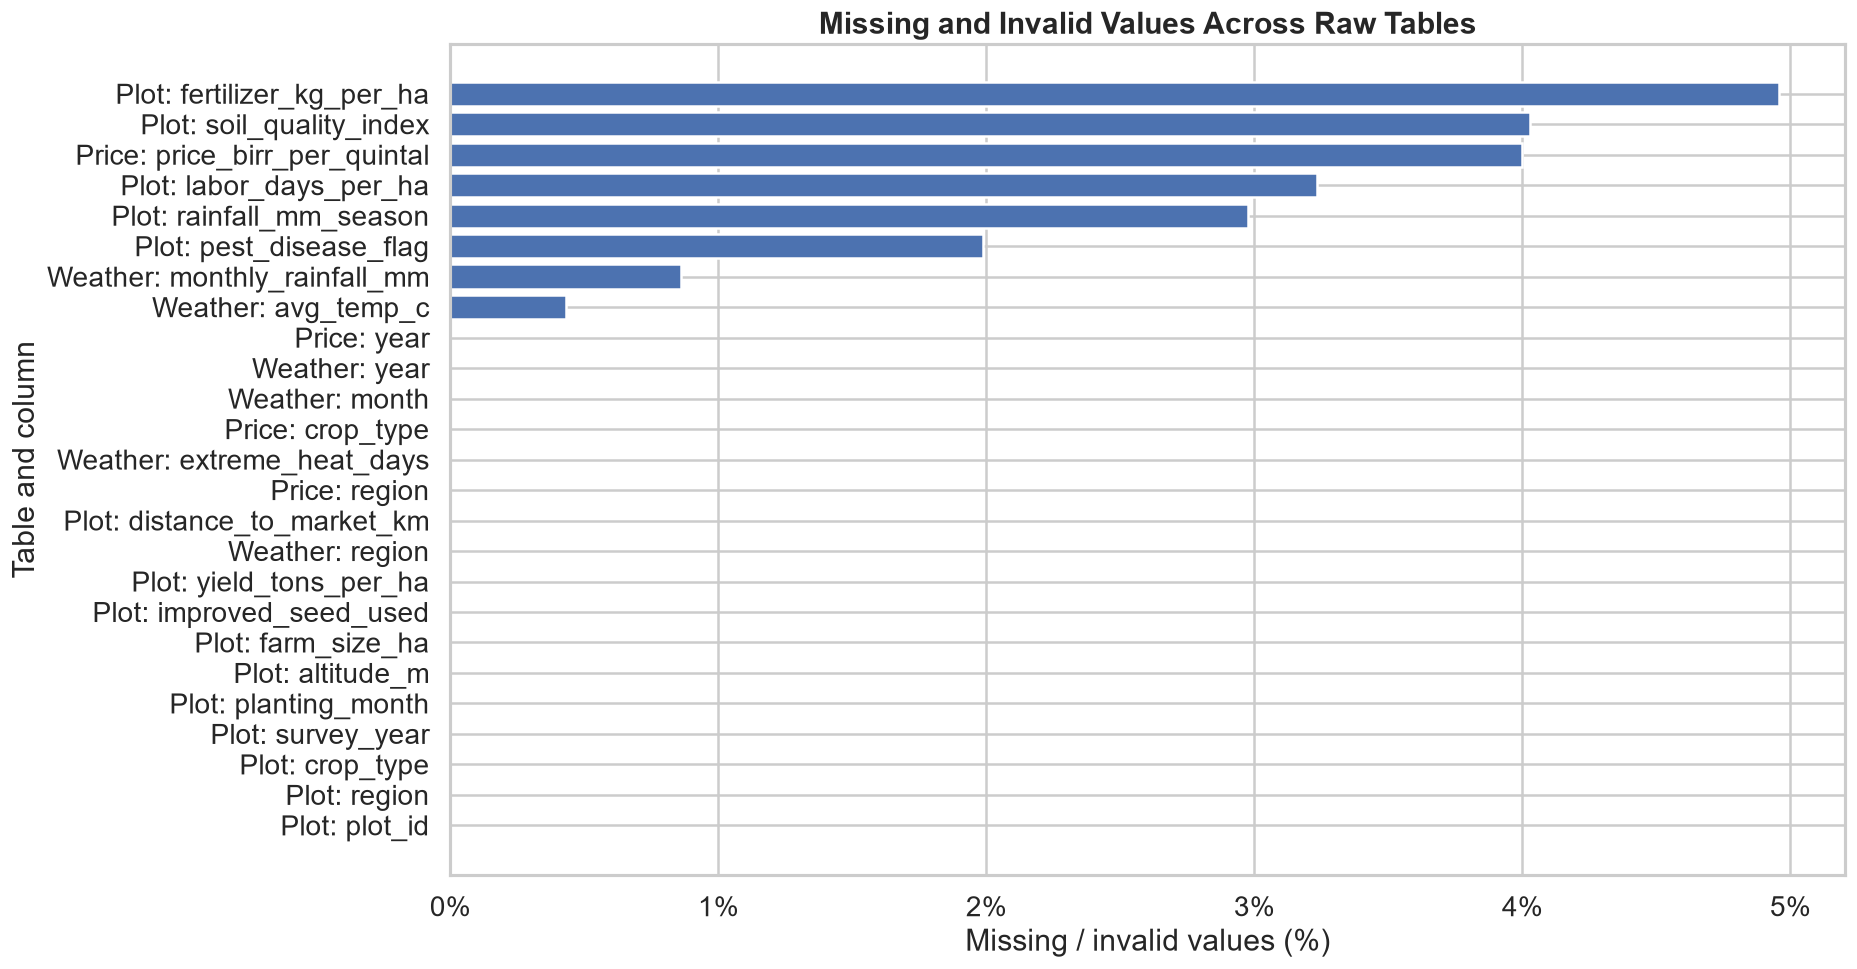

Saved: ..\figures\fig01_missingness.png


In [6]:
def invalid_rate_table(data, table_name):
    records = []

    for col in data.columns:
        series = data[col]

        missing = series.isna().sum()

        if pd.api.types.is_numeric_dtype(series):
            invalid = (series == -999).sum()
        else:
            invalid = 0

        total_invalid = missing + invalid

        records.append({
            "table": table_name,
            "column": col,
            "invalid_count": total_invalid,
            "invalid_pct": total_invalid / len(data) * 100
        })

    return pd.DataFrame(records)


missing_plot = invalid_rate_table(
    plot_raw,
    "Plot"
)

missing_weather = invalid_rate_table(
    weather_raw,
    "Weather"
)

missing_price = invalid_rate_table(
    price_raw,
    "Price"
)

missing_all = pd.concat(
    [
        missing_plot,
        missing_weather,
        missing_price
    ],
    ignore_index=True
)

missing_all["label"] = (
    missing_all["table"]
    + ": "
    + missing_all["column"]
)

missing_all = missing_all.sort_values(
    "invalid_pct",
    ascending=True
)

fig, ax = plt.subplots(
    figsize=(15, max(9, len(missing_all) * 0.25))
)

ax.barh(
    missing_all["label"],
    missing_all["invalid_pct"]
)

ax.set_title(
    "Missing and Invalid Values Across Raw Tables",
    fontweight="bold"
)

ax.set_xlabel("Missing / invalid values (%)")
ax.set_ylabel("Table and column")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:.0f}%")
)

save_figure(
    fig,
    "fig01_missingness.png"
)

## C2 — Figure 2: Before vs After Cleaning

Required file:

`fig02_before_after_cleaning.png`

Compares distributions before and after cleaning for variables where the cleaning pipeline changed the data.

The figure uses farm size, fertilizer, and price where the required raw and processed columns are available.

In [7]:
comparison_candidates = [
    ("farm_size_ha", "Farm size (ha)"),
    ("fertilizer_kg_per_ha", "Fertilizer (kg/ha)"),
    ("price_birr_per_quintal", "Price (Birr/quintal)")
]

available = [
    item for item in comparison_candidates
    if item[0] in plot_raw.columns or item[0] in price_raw.columns
]

print("Available comparison variables:", available)

Available comparison variables: [('farm_size_ha', 'Farm size (ha)'), ('fertilizer_kg_per_ha', 'Fertilizer (kg/ha)'), ('price_birr_per_quintal', 'Price (Birr/quintal)')]


TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'. Did you mean 'label'?

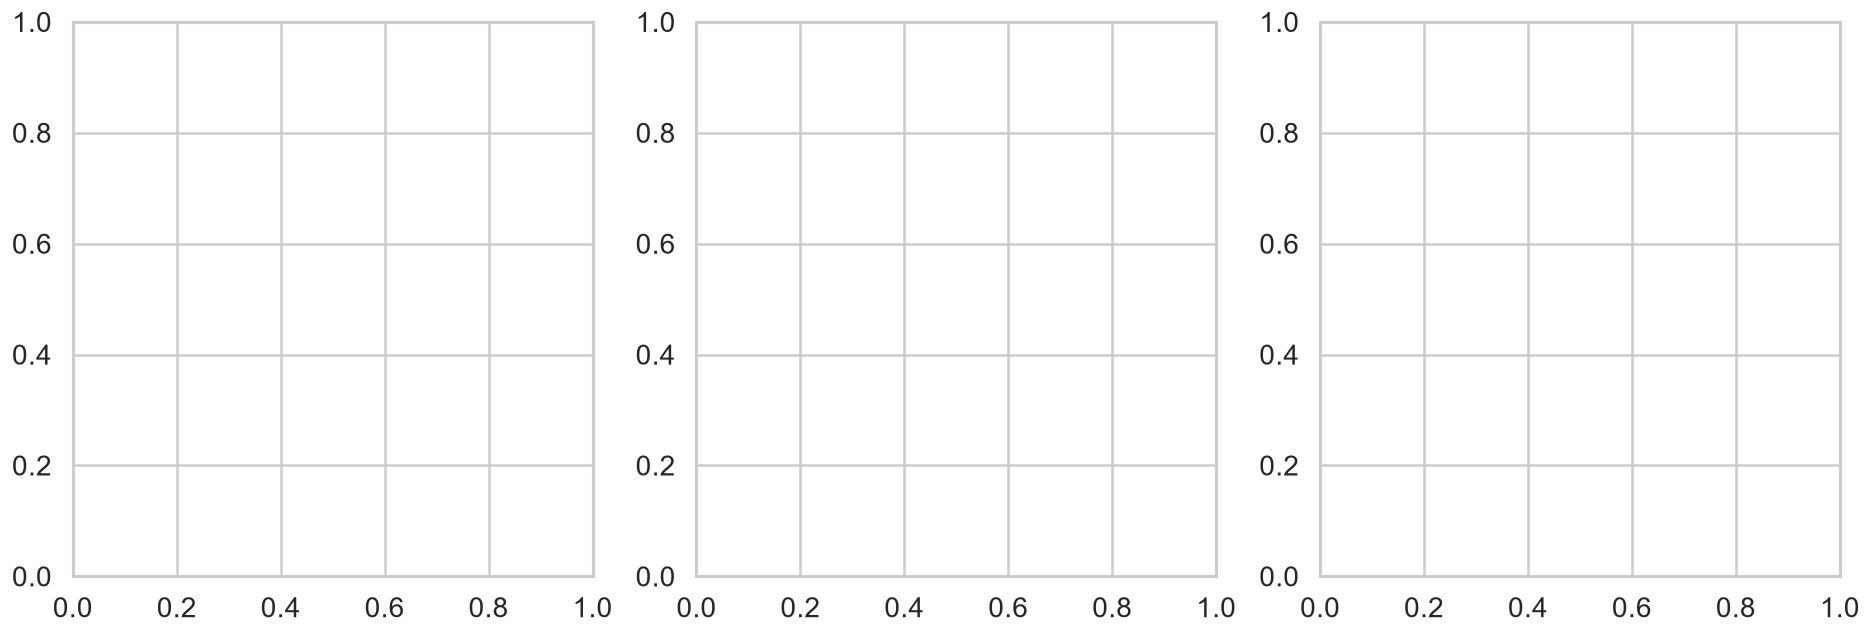

In [8]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(19, 6)
)

for ax, (column, label) in zip(axes, comparison_candidates):

    if column == "price_birr_per_quintal":
        before = price_raw[column].copy()
    elif column in plot_raw.columns:
        before = plot_raw[column].copy()
    else:
        ax.axis("off")
        continue

    if column not in df.columns:
        ax.axis("off")
        continue

    after = df[column].copy()

    before = pd.to_numeric(before, errors="coerce")
    after = pd.to_numeric(after, errors="coerce")

    before = before.replace(-999, np.nan).dropna()
    after = after.replace(-999, np.nan).dropna()

    ax.boxplot(
        [before, after],
        labels=["Before", "After"],
        showfliers=True
    )

    ax.set_title(label, fontweight="bold")
    ax.set_ylabel(label)

fig.suptitle(
    "Before-and-After Cleaning Distributions",
    fontweight="bold",
    y=1.03
)

save_figure(
    fig,
    "fig02_before_after_cleaning.png"
)

## C3 — Figure 3: Yield Distribution

Required file:

`fig03_yield_distribution.png`

Shows the overall distribution of yield and the distribution by crop type.

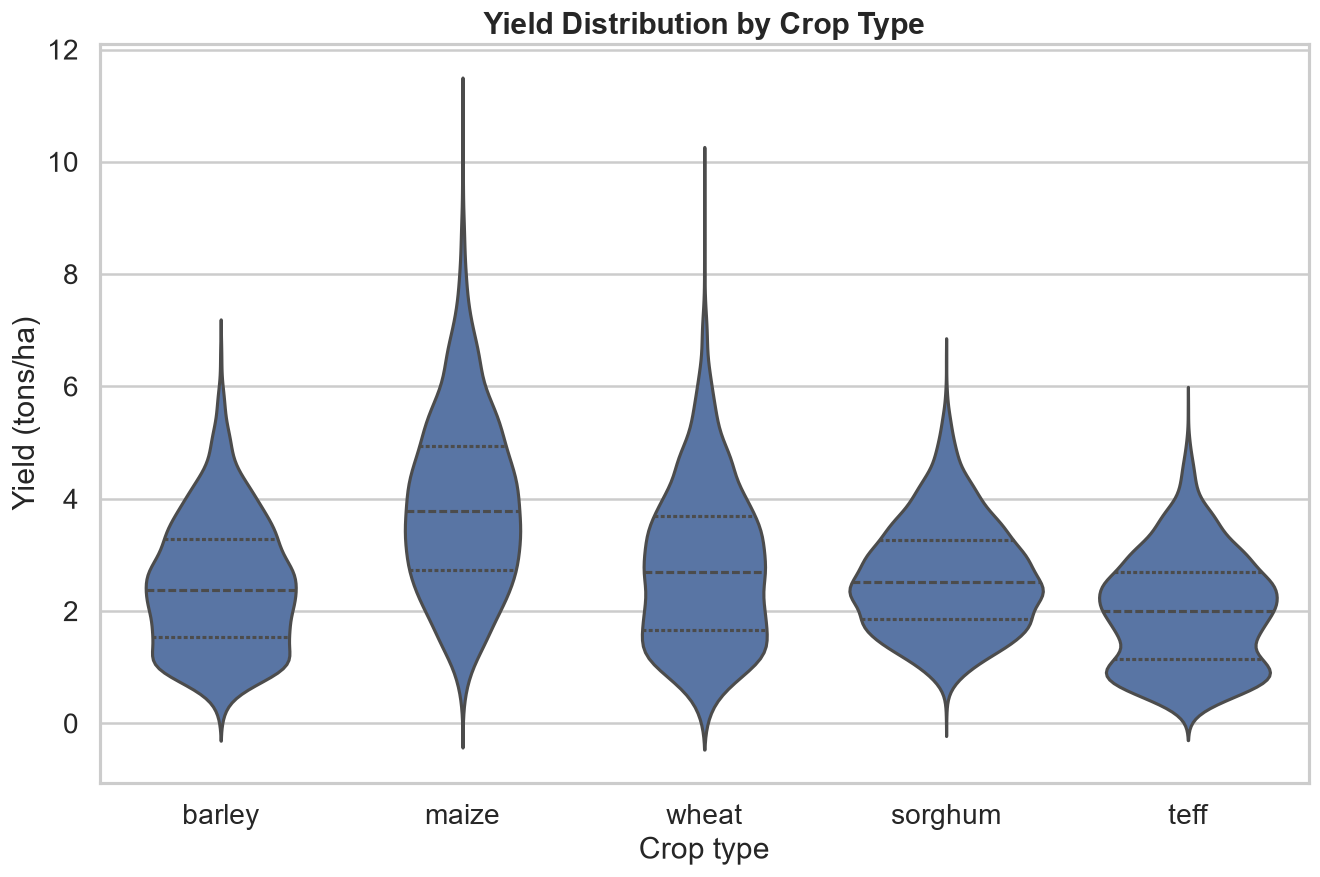

Saved: ..\figures\fig03_yield_distribution.png


In [9]:
fig, ax = plt.subplots(
    figsize=(13, 8)
)

sns.violinplot(
    data=df,
    x="crop_type",
    y="yield_tons_per_ha",
    inner="quartile",
    ax=ax
)

ax.set_title(
    "Yield Distribution by Crop Type",
    fontweight="bold"
)

ax.set_xlabel("Crop type")
ax.set_ylabel("Yield (tons/ha)")

save_figure(
    fig,
    "fig03_yield_distribution.png"
)

## C4 — Figure 4: Region × Crop Yield Heatmap

Required file:

`fig04_region_crop_heatmap.png`

Shows mean yield for every region × crop combination.

Cell annotations contain mean yield and plot count.

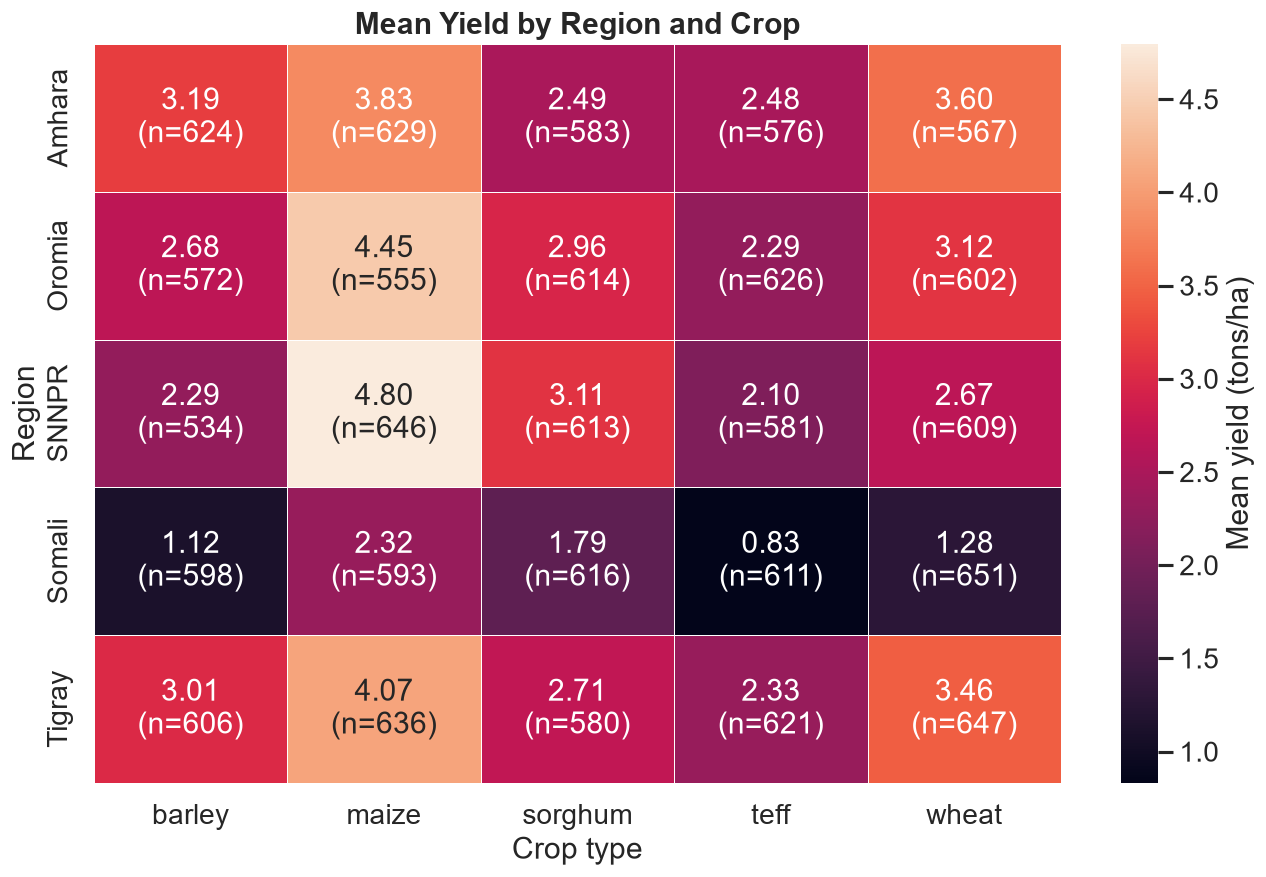

Saved: ..\figures\fig04_region_crop_heatmap.png


In [10]:
yield_pivot = pd.pivot_table(
    df,
    index="region",
    columns="crop_type",
    values="yield_tons_per_ha",
    aggfunc="mean"
)

count_pivot = pd.pivot_table(
    df,
    index="region",
    columns="crop_type",
    values="plot_id",
    aggfunc="count"
)

annot = yield_pivot.copy().astype(object)

for r in yield_pivot.index:
    for c in yield_pivot.columns:
        value = yield_pivot.loc[r, c]

        if pd.isna(value):
            annot.loc[r, c] = ""
        else:
            n = count_pivot.loc[r, c]
            annot.loc[r, c] = f"{value:.2f}\n(n={int(n)})"

fig, ax = plt.subplots(
    figsize=(13, 8)
)

sns.heatmap(
    yield_pivot,
    annot=annot,
    fmt="",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Mean yield (tons/ha)"}
)

ax.set_title(
    "Mean Yield by Region and Crop",
    fontweight="bold"
)

ax.set_xlabel("Crop type")
ax.set_ylabel("Region")

save_figure(
    fig,
    "fig04_region_crop_heatmap.png"
)

## C5 — Figure 5: Correlation Heatmap

Required file:

`fig05_correlation_heatmap.png`

Shows correlations between yield, numeric plot-level features, and weather-derived numeric features.

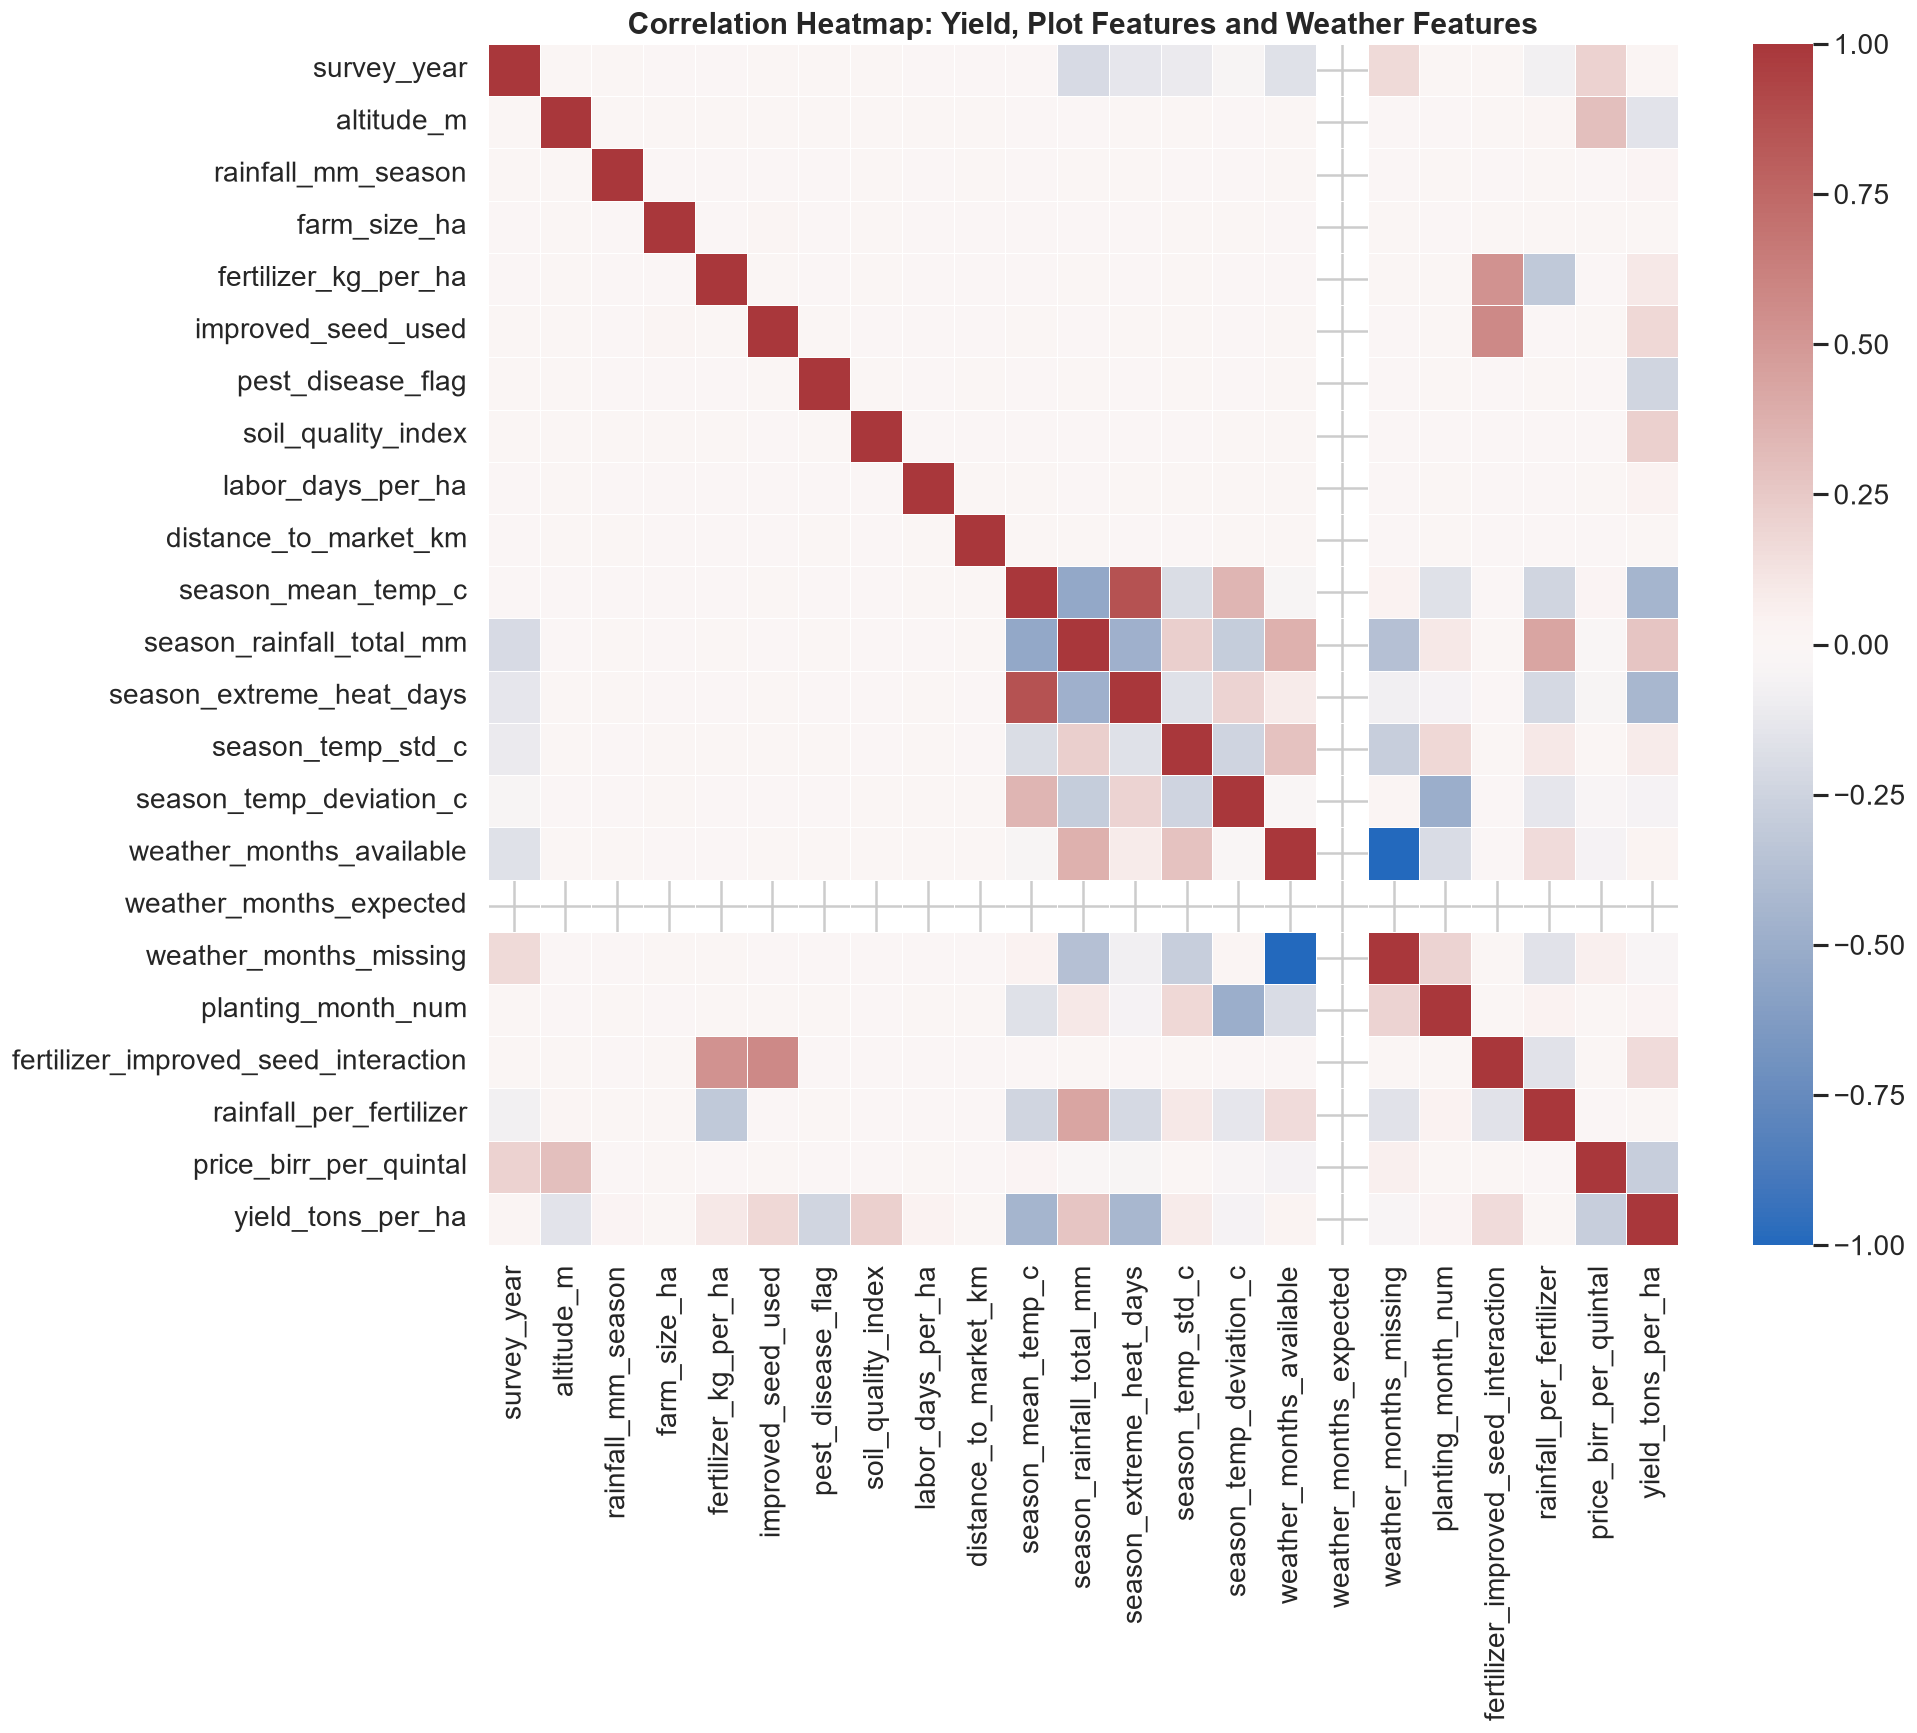

Saved: ..\figures\fig05_correlation_heatmap.png


In [11]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns.tolist()

numeric_cols = [
    c for c in numeric_cols
    if c not in ["plot_id"]
]

corr = df[numeric_cols].corr()

# Keep the visualization readable
if len(corr.columns) > 25:
    target_corr = (
        corr["yield_tons_per_ha"]
        .abs()
        .sort_values(ascending=False)
        .head(25)
        .index
    )
    corr = corr.loc[target_corr, target_corr]

fig, ax = plt.subplots(
    figsize=(16, 13)
)

sns.heatmap(
    corr,
    cmap="vlag",
    center=0,
    linewidths=0.3,
    ax=ax
)

ax.set_title(
    "Correlation Heatmap: Yield, Plot Features and Weather Features",
    fontweight="bold"
)

save_figure(
    fig,
    "fig05_correlation_heatmap.png"
)

## C6 — Figure 6: Climate by Region

Required file:

`fig06_climate_by_region.png`

Shows monthly average temperature across regions and highlights a four-month growing-season window.

The hackathon allows the growing season to be defined as the planting month plus the following three months, provided the rule is documented.

In [12]:
weather_temp_col = None

for c in [
    "avg_temp_c",
    "mean_temperature",
    "monthly_avg_temp_c"
]:
    if c in weather_raw.columns:
        weather_temp_col = c
        break

weather_month_col = None

for c in [
    "month",
    "month_num"
]:
    if c in weather_raw.columns:
        weather_month_col = c
        break

print("Temperature:", weather_temp_col)
print("Month:", weather_month_col)

Temperature: avg_temp_c
Month: month


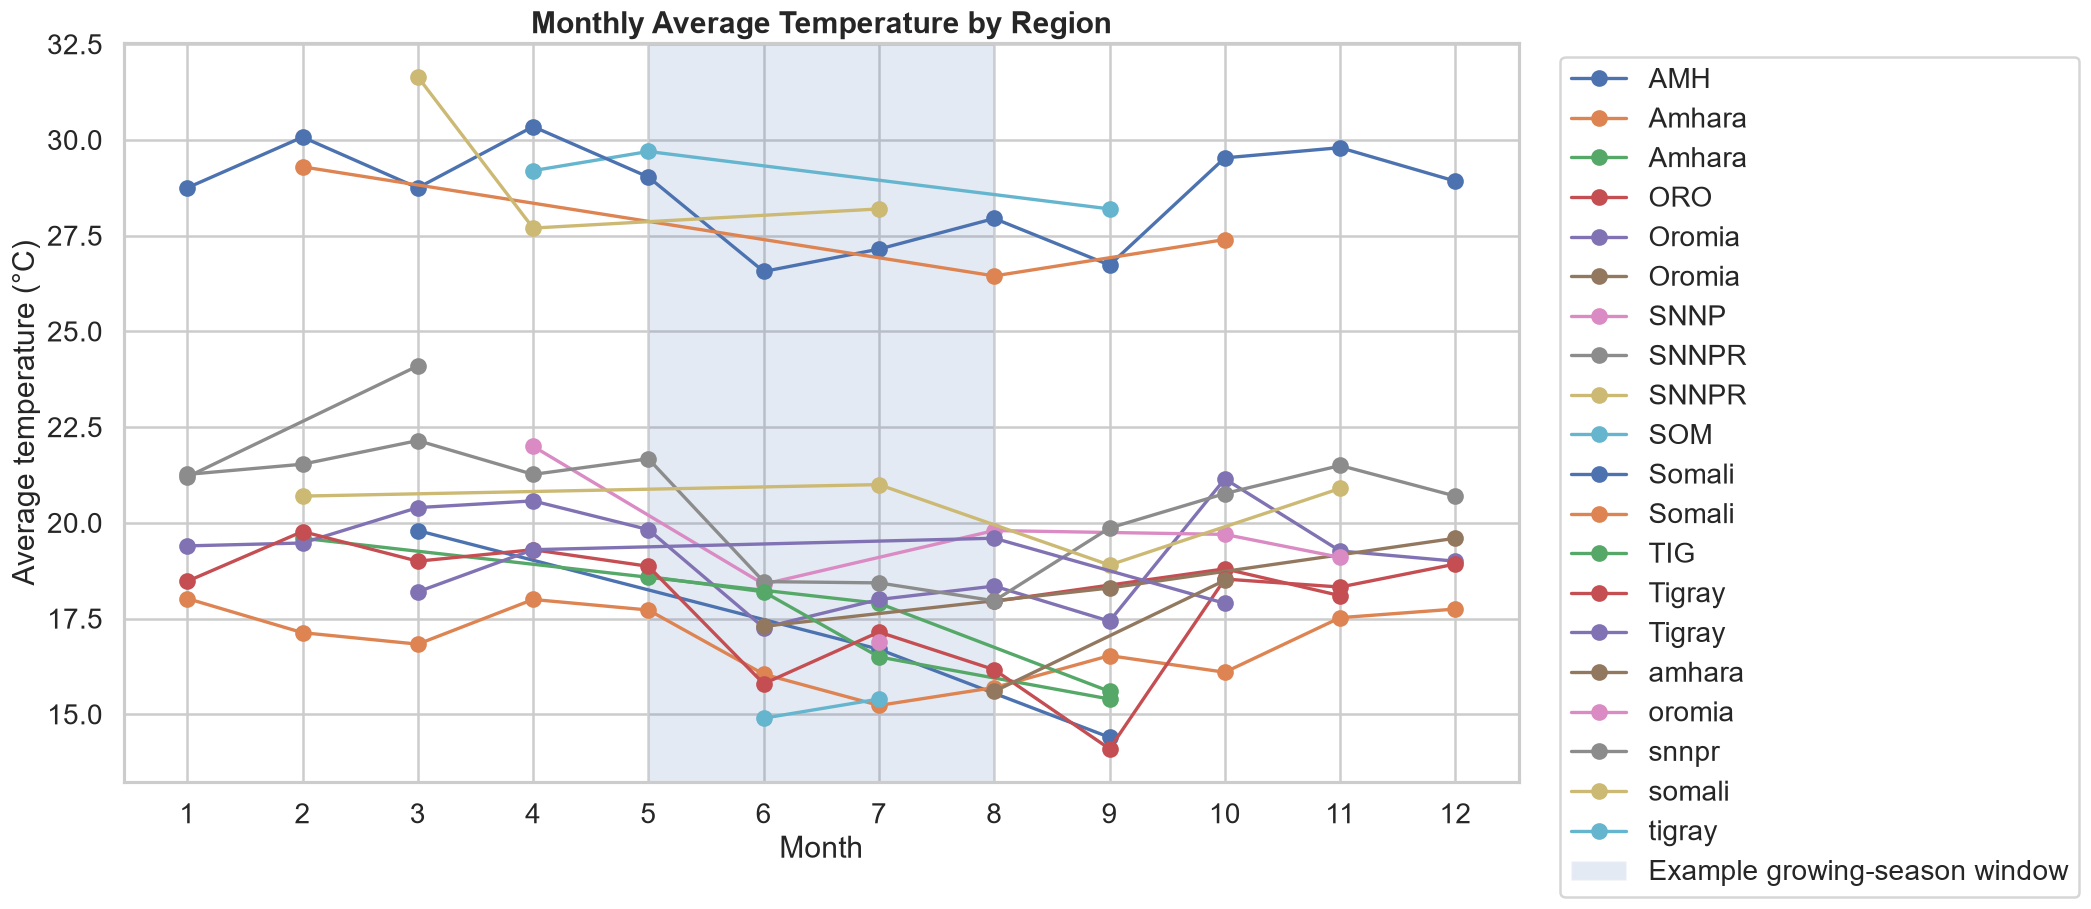

Saved: ..\figures\fig06_climate_by_region.png


In [13]:
if weather_temp_col is None or weather_month_col is None:
    print(
        "Weather monthly columns were not found. "
        "Check the raw weather column names."
    )
else:

    climate = weather_raw.copy()

    month_map = {
        "jan": 1, "january": 1,
        "feb": 2, "february": 2,
        "mar": 3, "march": 3,
        "apr": 4, "april": 4,
        "may": 5,
        "jun": 6, "june": 6,
        "jul": 7, "july": 7,
        "aug": 8, "august": 8,
        "sep": 9, "september": 9,
        "oct": 10, "october": 10,
        "nov": 11, "november": 11,
        "dec": 12, "december": 12
    }

    climate["month_num"] = (
        climate[weather_month_col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(month_map)
    )

    climate[weather_temp_col] = pd.to_numeric(
        climate[weather_temp_col],
        errors="coerce"
    )

    climate = climate.dropna(
        subset=["month_num", weather_temp_col]
    )

    monthly_climate = (
        climate.groupby(
            ["region", "month_num"]
        )[weather_temp_col]
        .mean()
        .reset_index()
    )

    fig, ax = plt.subplots(
        figsize=(15, 8)
    )

    for region, group in monthly_climate.groupby("region"):
        group = group.sort_values("month_num")

        ax.plot(
            group["month_num"],
            group[weather_temp_col],
            marker="o",
            linewidth=2,
            label=region
        )

    # Example four-month growing-season window
    # starting from May; adjust only if your documented season rule differs.
    ax.axvspan(
        5,
        8,
        alpha=0.15,
        label="Example growing-season window"
    )

    ax.set_title(
        "Monthly Average Temperature by Region",
        fontweight="bold"
    )

    ax.set_xlabel("Month")
    ax.set_ylabel("Average temperature (°C)")
    ax.set_xticks(range(1, 13))

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    save_figure(
        fig,
        "fig06_climate_by_region.png"
    )

## C7 — Figure 7: Yield vs Growing-Season Temperature

Required file:

`fig07_yield_vs_season_temp.png`

Shows yield against growing-season mean temperature with one panel per crop and a fitted trend line.

In [16]:
temperature_candidates = [
    "season_mean_temp_c",
    "growing_season_mean_temperature",
    "growing_season_mean_temp",
    "season_mean_temperature",
    "season_mean_temp",
    "mean_temperature",
]

season_temp_col = None
for c in temperature_candidates:
    if c in df.columns:
        season_temp_col = c
        break

print("Growing-season temperature column:", season_temp_col)

Growing-season temperature column: season_mean_temp_c


In [ ]:
if season_temp_col is None:
    print(
        "No growing-season temperature feature found. "
        "Use the exact weather-derived column created in Notebook 01."
    )
else:

    crops = sorted(df["crop_type"].dropna().unique())

    n = len(crops)

    fig, axes = plt.subplots(
        1,
        n,
        figsize=(5 * n, 5),
        squeeze=False
    )

    axes = axes.ravel()

    for ax, crop in zip(axes, crops):

        subset = df[
            df["crop_type"] == crop
        ][
            [season_temp_col, "yield_tons_per_ha"]
        ].dropna()

        sns.scatterplot(
            data=subset,
            x=season_temp_col,
            y="yield_tons_per_ha",
            alpha=0.35,
            ax=ax
        )

        if len(subset) >= 5:
            sns.regplot(
                data=subset,
                x=season_temp_col,
                y="yield_tons_per_ha",
                scatter=False,
                ax=ax
            )

        ax.set_title(
            crop.title(),
            fontweight="bold"
        )

        ax.set_xlabel(
            "Growing-season mean temperature (°C)"
        )

        ax.set_ylabel(
            "Yield (tons/ha)"
        )

    fig.suptitle(
        "Yield vs Growing-Season Mean Temperature by Crop",
        fontweight="bold",
        y=1.02
    )

    save_figure(
        fig,
        "fig07_yield_vs_season_temp.png"
    )

## C8 — Figure 8: Price Trends

Required file:

`fig08_price_trends.png`

Shows average price per quintal by year for every crop.

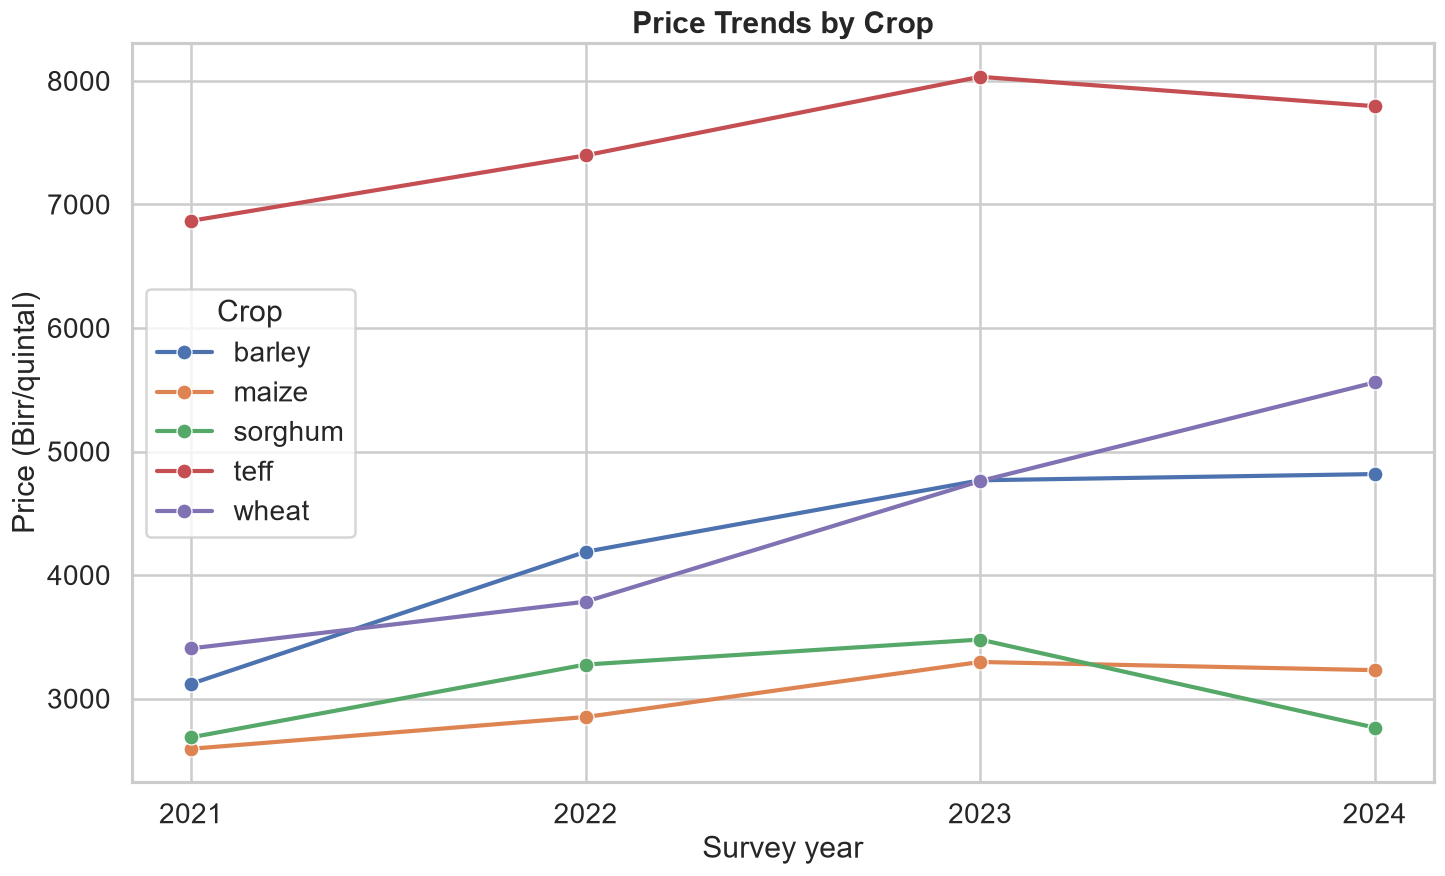

Saved: ..\figures\fig08_price_trends.png


In [17]:
price_df = df[
    [
        "crop_type",
        "survey_year",
        "price_birr_per_quintal"
    ]
].dropna()

price_trend = (
    price_df
    .groupby(
        ["survey_year", "crop_type"]
    )["price_birr_per_quintal"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(
    figsize=(14, 8)
)

sns.lineplot(
    data=price_trend,
    x="survey_year",
    y="price_birr_per_quintal",
    hue="crop_type",
    marker="o",
    linewidth=2.5,
    ax=ax
)

ax.set_title(
    "Price Trends by Crop",
    fontweight="bold"
)

ax.set_xlabel("Survey year")
ax.set_ylabel("Price (Birr/quintal)")
ax.set_xticks(sorted(price_trend["survey_year"].unique()))

ax.legend(
    title="Crop"
)

save_figure(
    fig,
    "fig08_price_trends.png"
)

## C9 — Figure 9: Revenue by Crop and Region

Required file:

`fig09_revenue_by_crop_region.png`

Shows estimated revenue per hectare by crop and region.

Revenue is calculated as:

yield × 10 quintals/ton × price per quintal.

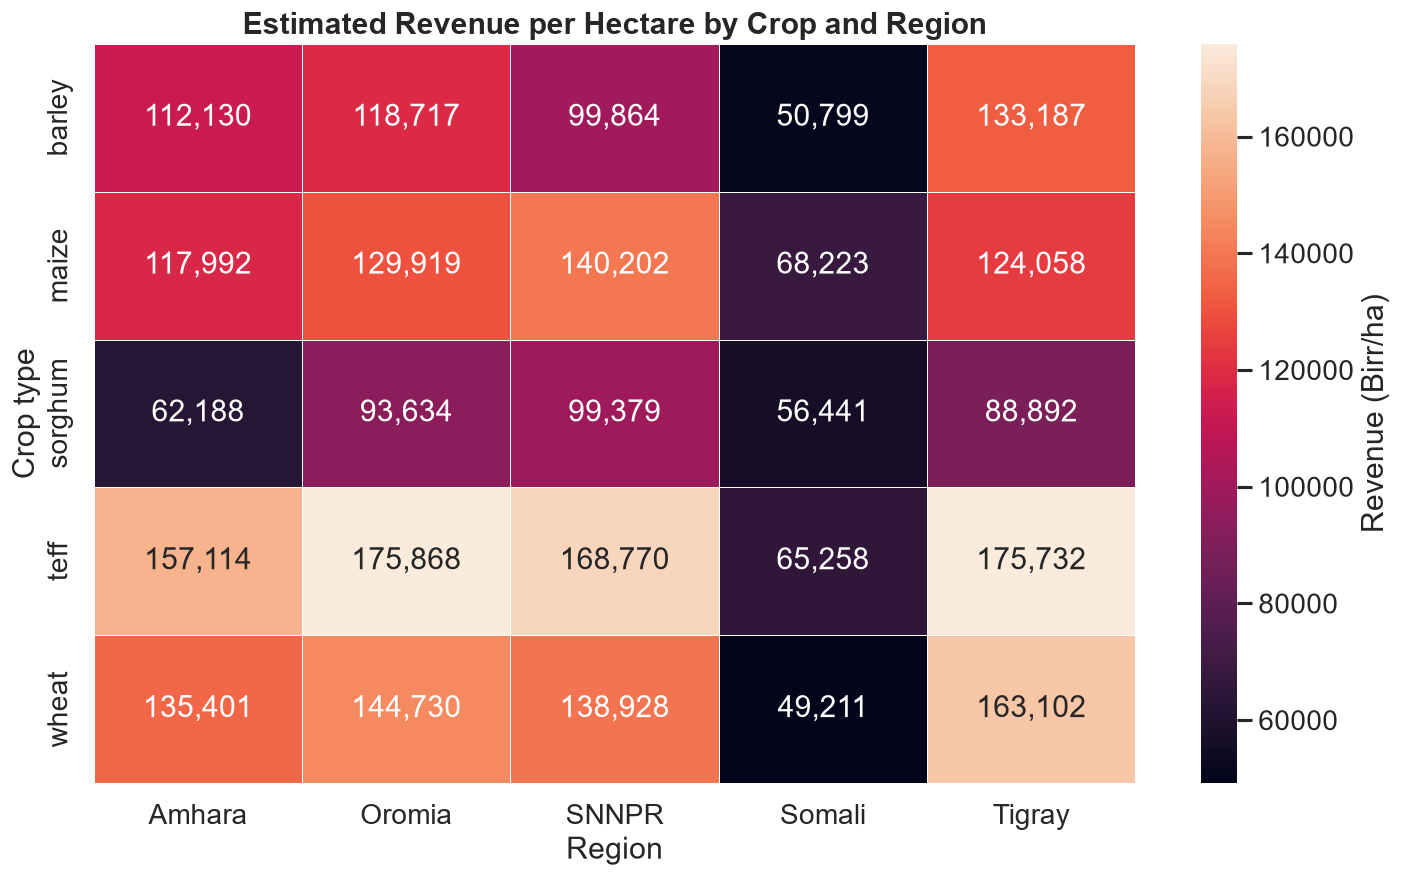

Saved: ..\figures\fig09_revenue_by_crop_region.png


In [18]:
df["revenue_birr_per_ha"] = (
    df["yield_tons_per_ha"]
    * 10
    * df["price_birr_per_quintal"]
)

revenue = (
    df.groupby(
        ["crop_type", "region"]
    )["revenue_birr_per_ha"]
    .mean()
    .reset_index()
)

revenue_pivot = revenue.pivot(
    index="crop_type",
    columns="region",
    values="revenue_birr_per_ha"
)

fig, ax = plt.subplots(
    figsize=(14, 8)
)

sns.heatmap(
    revenue_pivot,
    annot=True,
    fmt=",.0f",
    linewidths=0.5,
    ax=ax,
    cbar_kws={
        "label": "Revenue (Birr/ha)"
    }
)

ax.set_title(
    "Estimated Revenue per Hectare by Crop and Region",
    fontweight="bold"
)

ax.set_xlabel("Region")
ax.set_ylabel("Crop type")

save_figure(
    fig,
    "fig09_revenue_by_crop_region.png"
)

## C10–C12 — Modeling outputs

Figures 10–12 depend on the validation/modeling results produced in Notebook 04.

Expected files:

- `reports/model_results.csv`
- `reports/validation_predictions.csv`
- `reports/feature_importance.csv`

If these files do not yet exist, these figures are intentionally not fabricated.
Run Notebook 04 first and then return to this section.

In [25]:
model_results_path = PROJECT_ROOT / "reports" / "model_results.csv"
predictions_path = PROJECT_ROOT / "reports" / "validation_predictions.csv"
importance_path = PROJECT_ROOT / "reports" / "feature_importance.csv"

print("Model results:", model_results_path.exists())
print("Validation predictions:", predictions_path.exists())
print("Feature importance:", importance_path.exists())

Model results: True
Validation predictions: True
Feature importance: True


### Figure 10

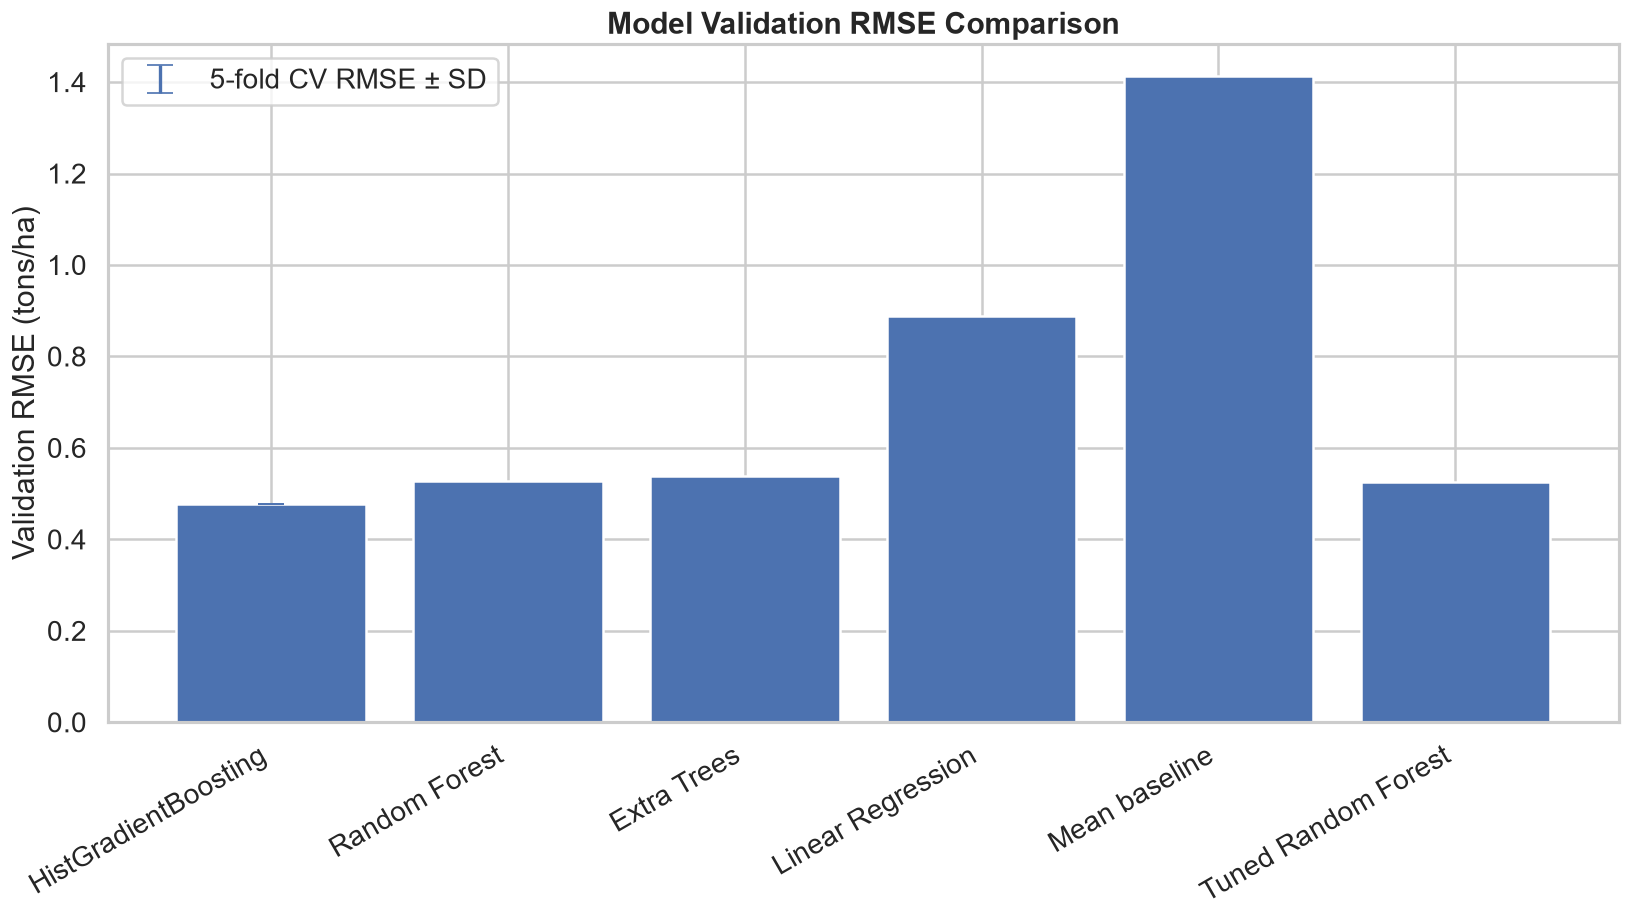

In [31]:
model_results = pd.read_csv(
    PROJECT_ROOT / "reports" / "model_results.csv"
)

fig, ax = plt.subplots(
    figsize=(14, 8)
)

x = np.arange(len(model_results))

ax.bar(
    x,
    model_results["rmse"]
)

# Add final-model CV error bar
winner_name = (
    model_results
    .sort_values("rmse")
    .iloc[0]["model"]
)

final_idx = model_results["model"].eq(winner_name)

# Use the std RMSE column if available; otherwise create a zero-width fallback
if "std_rmse" in model_results.columns:
    final_cv = model_results.loc[final_idx, ["std_rmse"]].iloc[0]
else:
    final_cv = pd.Series({"std_rmse": 0.0})

if final_idx.any():
    idx = np.where(final_idx)[0][0]

    ax.errorbar(
        idx,
        model_results.loc[idx, "rmse"],
        yerr=final_cv["std_rmse"],
        fmt="none",
        capsize=8,
        linewidth=2,
        label="5-fold CV RMSE ± SD"
    )

ax.set_xticks(x)
ax.set_xticklabels(
    model_results["model"],
    rotation=30,
    ha="right"
)

ax.set_ylabel("Validation RMSE (tons/ha)")
ax.set_title(
    "Model Validation RMSE Comparison",
    fontweight="bold"
)

ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "fig10_model_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()
plt.close()

,model,rmse,mae,r2,training_time_sec
0,HistGradientBoosting,0.477949,0.345593,0.885581,2.781361
1,Random Forest,0.527944,0.386170,0.860392,1.882678
2,Extra Trees,0.537597,0.392942,0.855241,1.119097
3,Linear Regression,0.888704,0.665279,0.604407,0.096017
4,Mean baseline,1.413051,1.104234,-0.000113,0.026823
5,Tuned Random Forest,0.526044,0.384828,0.861396,38.594052


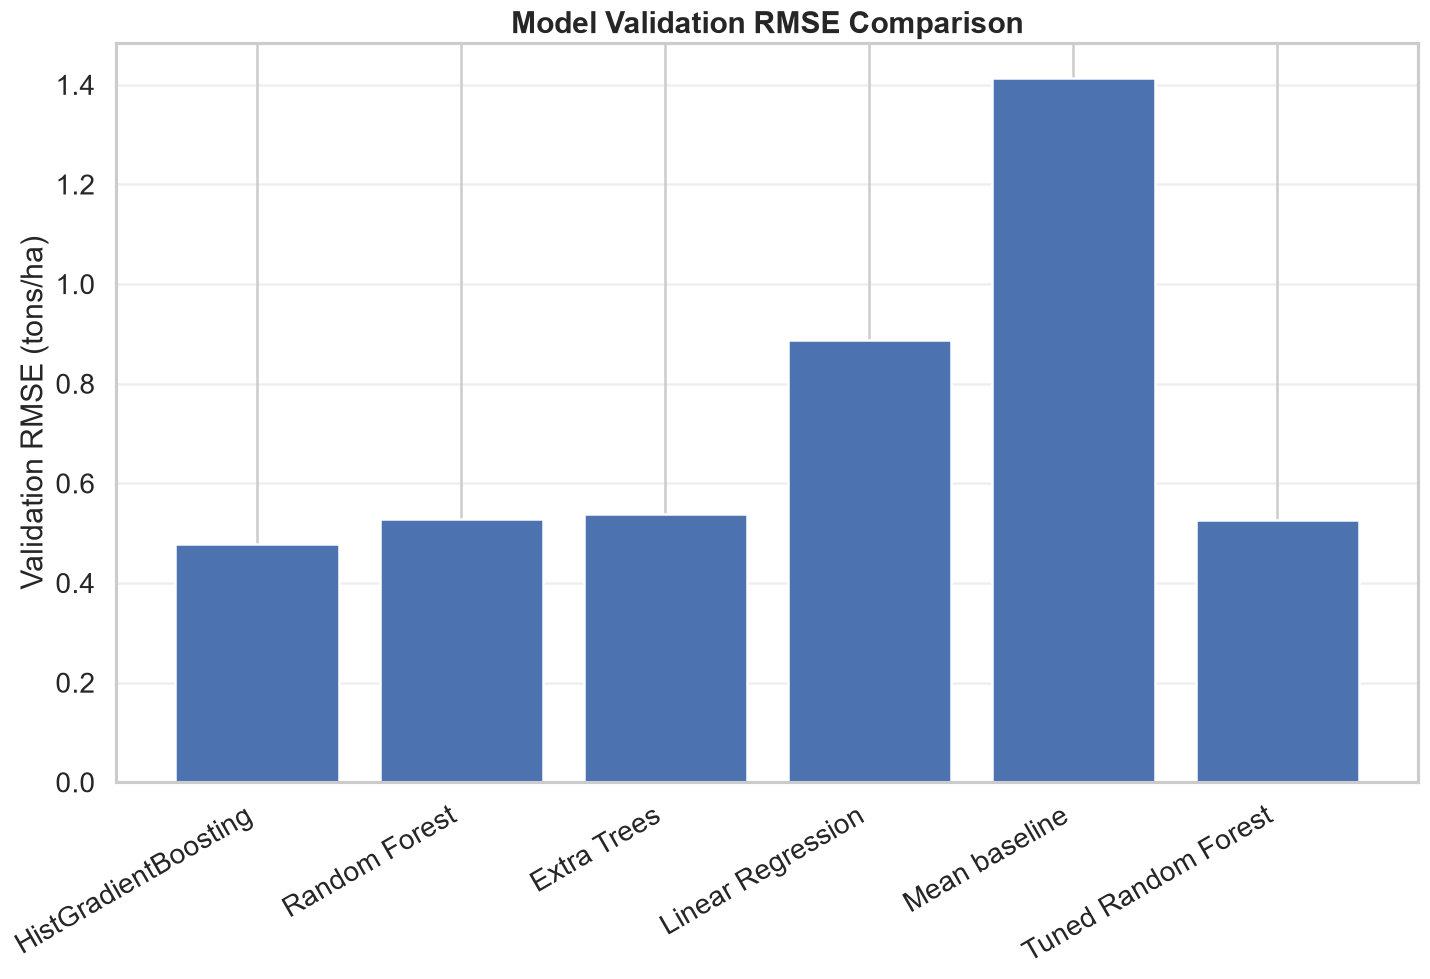

Saved: ..\figures\fig10_model_comparison.png


In [26]:
if not model_results_path.exists():

    print(
        "fig10 skipped for now: reports/model_results.csv does not exist."
    )

else:

    model_results = pd.read_csv(
        model_results_path
    )

    display(model_results)

    fig, ax = plt.subplots(
        figsize=(14, 8)
    )

    x = np.arange(len(model_results))

    rmse = model_results["rmse"]

    ax.bar(
        x,
        rmse
    )

    ax.set_xticks(x)

    ax.set_xticklabels(
        model_results["model"],
        rotation=30,
        ha="right"
    )

    ax.set_ylabel(
        "Validation RMSE (tons/ha)"
    )

    ax.set_title(
        "Model Validation RMSE Comparison",
        fontweight="bold"
    )

    ax.grid(
        axis="y",
        alpha=0.3
    )

    save_figure(
        fig,
        "fig10_model_comparison.png"
    )

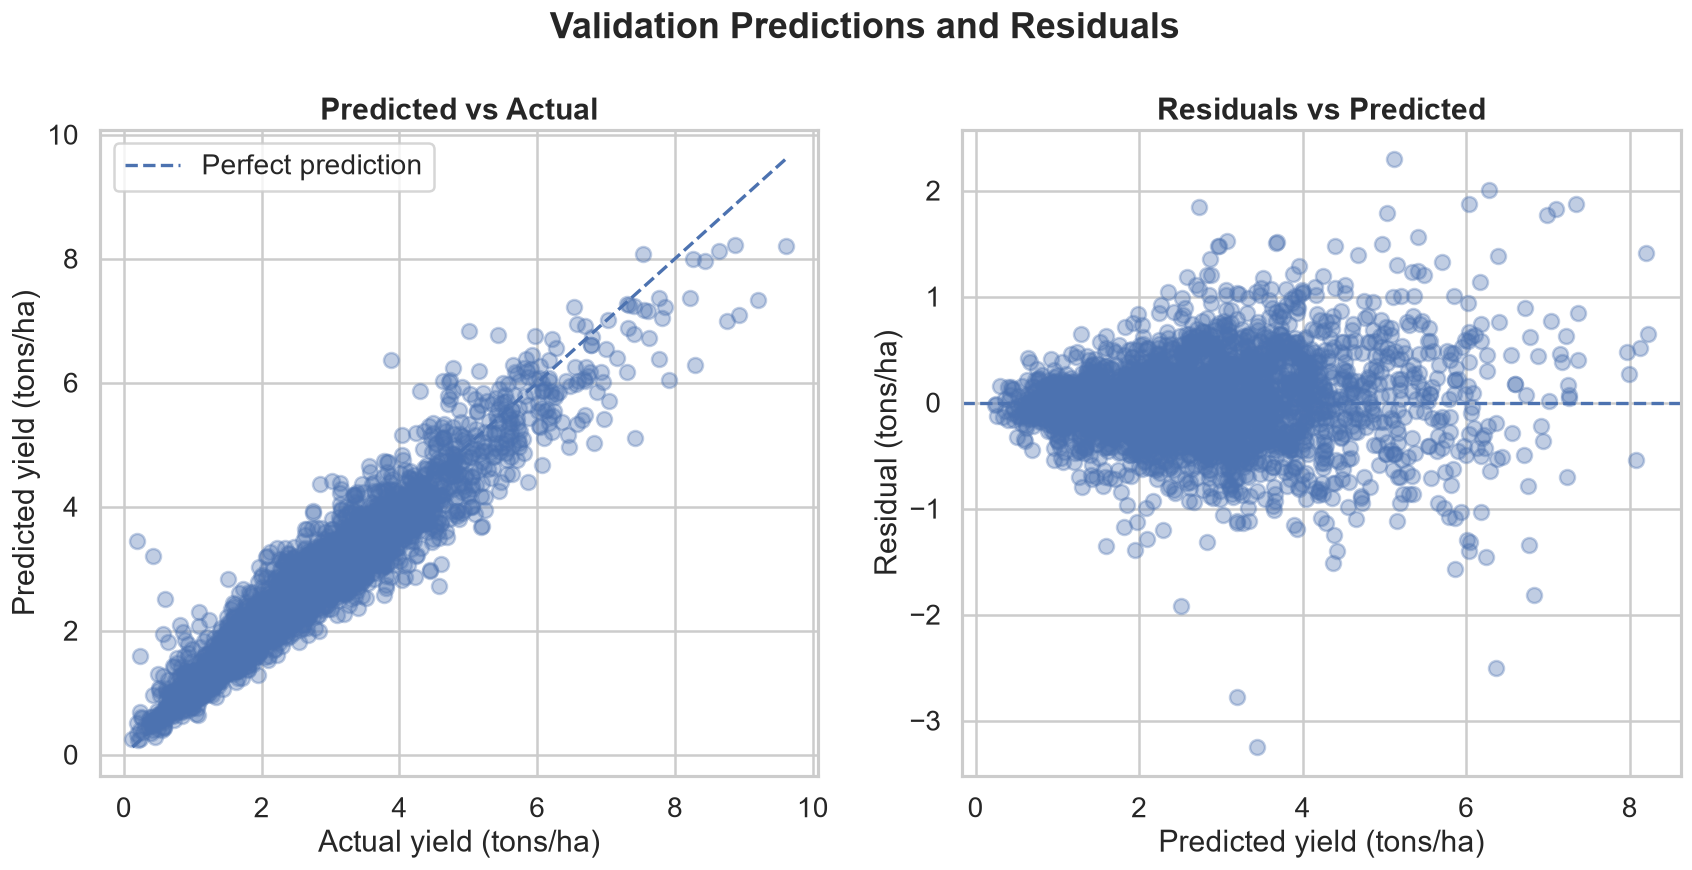

Saved: ..\figures\fig11_predicted_vs_actual_residuals.png


In [27]:
if not predictions_path.exists():

    print(
        "fig11 skipped for now: reports/validation_predictions.csv does not exist."
    )

else:

    pred = pd.read_csv(
        predictions_path
    )

    # Accept common column names
    actual_candidates = [
        "actual",
        "y_true",
        "yield_tons_per_ha"
    ]

    predicted_candidates = [
        "predicted",
        "y_pred",
        "predicted_yield_tons_per_ha"
    ]

    actual_col = next(
        (c for c in actual_candidates if c in pred.columns),
        None
    )

    predicted_col = next(
        (c for c in predicted_candidates if c in pred.columns),
        None
    )

    if actual_col is None or predicted_col is None:
        raise ValueError(
            "Could not identify actual/predicted columns in validation_predictions.csv"
        )

    pred["residual"] = (
        pred[actual_col]
        - pred[predicted_col]
    )

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(17, 7)
    )

    # Predicted vs actual
    axes[0].scatter(
        pred[actual_col],
        pred[predicted_col],
        alpha=0.35
    )

    minimum = min(
        pred[actual_col].min(),
        pred[predicted_col].min()
    )

    maximum = max(
        pred[actual_col].max(),
        pred[predicted_col].max()
    )

    axes[0].plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        linewidth=2,
        label="Perfect prediction"
    )

    axes[0].set_title(
        "Predicted vs Actual",
        fontweight="bold"
    )

    axes[0].set_xlabel(
        "Actual yield (tons/ha)"
    )

    axes[0].set_ylabel(
        "Predicted yield (tons/ha)"
    )

    axes[0].legend()

    # Residuals
    axes[1].scatter(
        pred[predicted_col],
        pred["residual"],
        alpha=0.35
    )

    axes[1].axhline(
        0,
        linestyle="--",
        linewidth=2
    )

    axes[1].set_title(
        "Residuals vs Predicted",
        fontweight="bold"
    )

    axes[1].set_xlabel(
        "Predicted yield (tons/ha)"
    )

    axes[1].set_ylabel(
        "Residual (tons/ha)"
    )

    fig.suptitle(
        "Validation Predictions and Residuals",
        fontweight="bold",
        y=1.02
    )

    save_figure(
        fig,
        "fig11_predicted_vs_actual_residuals.png"
    )

Feature importance columns:
['feature', 'importance', 'importance_std']


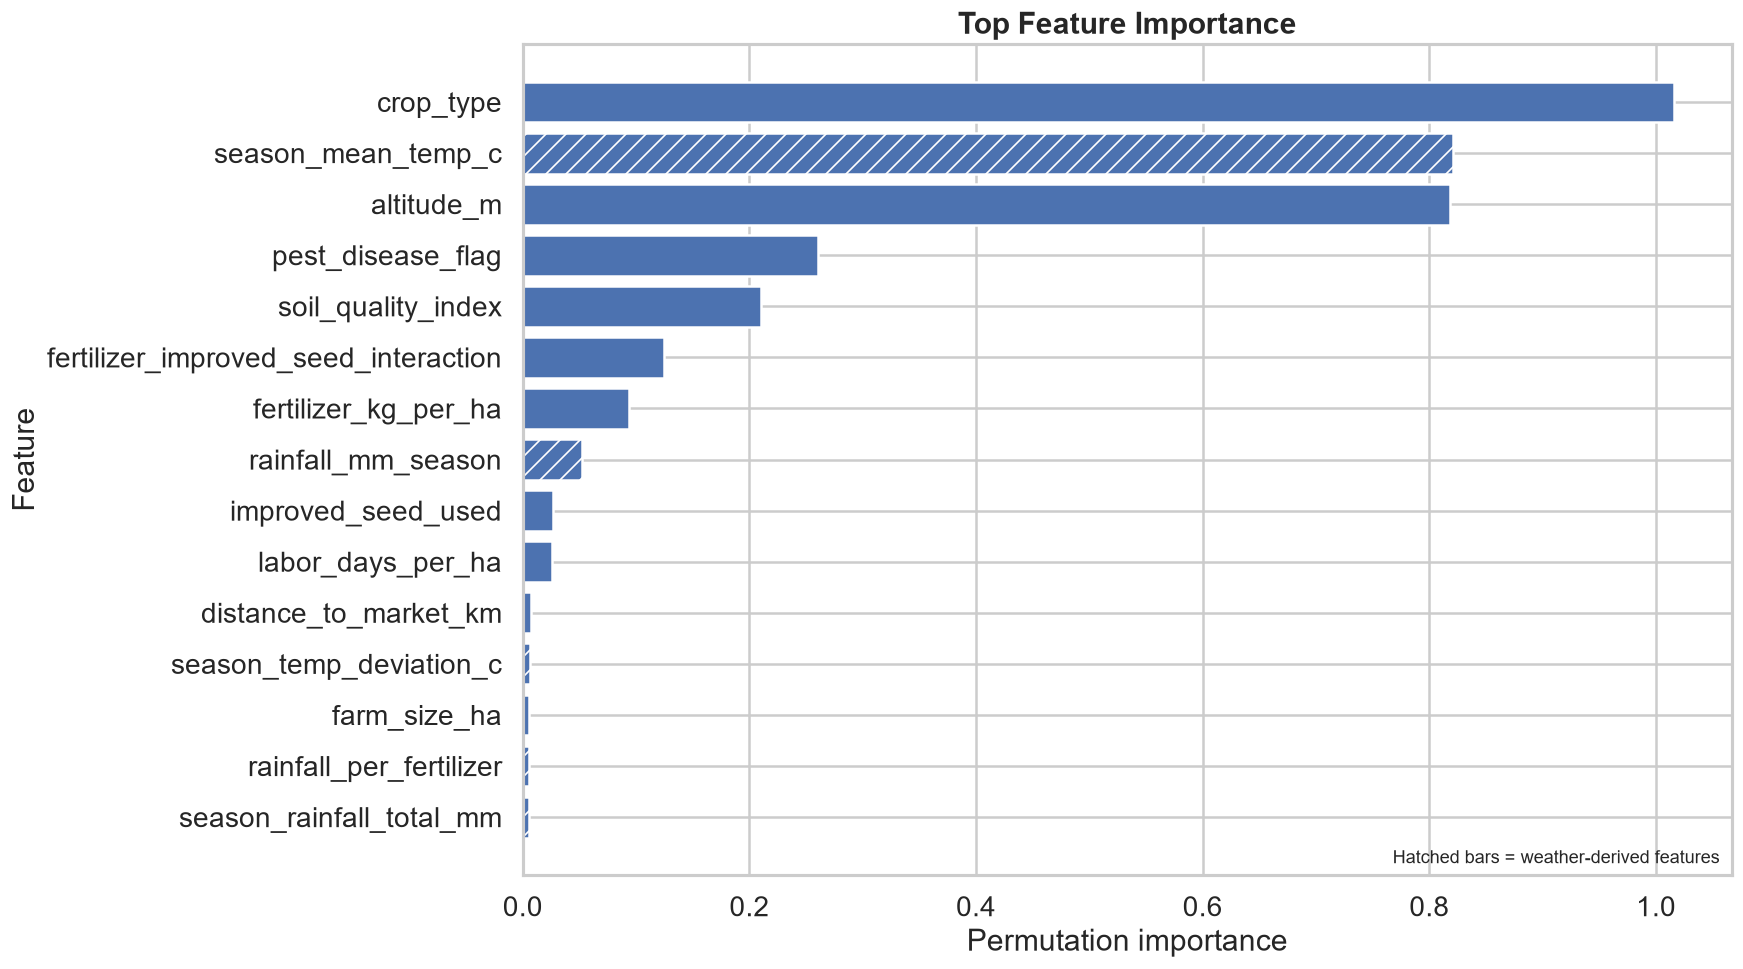

Saved: ..\figures\fig12_feature_importance.png


In [28]:
if not importance_path.exists():

    print(
        "fig12 skipped for now: reports/feature_importance.csv does not exist."
    )

else:

    importance = pd.read_csv(
        importance_path
    )

    print("Feature importance columns:")
    print(importance.columns.tolist())

    # Expected structure:
    # feature, importance
    if "feature" not in importance.columns:
        raise ValueError(
            "feature_importance.csv must contain a 'feature' column."
        )

    importance_col_candidates = [
        "importance",
        "mean_importance",
        "permutation_importance"
    ]

    importance_col = next(
        (
            c for c in importance_col_candidates
            if c in importance.columns
        ),
        None
    )

    if importance_col is None:
        raise ValueError(
            "Could not identify the importance column."
        )

    top = (
        importance
        .sort_values(
            importance_col,
            ascending=False
        )
        .head(15)
        .sort_values(
            importance_col,
            ascending=True
        )
    )

    weather_words = [
        "temp",
        "temperature",
        "rain",
        "rainfall",
        "weather",
        "heat",
        "season"
    ]

    is_weather = top["feature"].str.lower().apply(
        lambda x: any(
            word in x
            for word in weather_words
        )
    )

    fig, ax = plt.subplots(
        figsize=(13, 9)
    )

    bars = ax.barh(
        top["feature"],
        top[importance_col]
    )

    for bar, weather in zip(
        bars,
        is_weather
    ):
        if weather:
            bar.set_hatch("//")

    ax.set_title(
        "Top Feature Importance",
        fontweight="bold"
    )

    ax.set_xlabel(
        "Permutation importance"
    )

    ax.set_ylabel(
        "Feature"
    )

    ax.text(
        0.99,
        0.01,
        "Hatched bars = weather-derived features",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=11
    )

    save_figure(
        fig,
        "fig12_feature_importance.png"
    )

## Figure captions

In [23]:
captions_path = FIGURES_DIR / "figure_captions.md"

captions = """# Visualization Pack — Figure Captions

## fig01_missingness.png
Shows the share of missing or invalid values, including -999 sentinels, across the three raw tables. The figure highlights which source columns required the most cleaning attention.

## fig02_before_after_cleaning.png
Compares selected variable distributions before and after cleaning. The takeaway is whether the cleaning rules materially changed the observed distributions.

## fig03_yield_distribution.png
Shows the distribution of yield across crop types. Differences in the shape, center, and spread indicate that crop type is an important descriptive dimension of yield.

## fig04_region_crop_heatmap.png
Shows mean yield for every region × crop combination, with plot counts annotated. The strongest and weakest combinations identify important geographic and crop-specific differences.

## fig05_correlation_heatmap.png
Shows correlations between yield, numeric plot-level variables, and weather-derived features. Strong correlations identify candidate drivers for further modeling investigation but do not by themselves establish causality.

## fig06_climate_by_region.png
Shows monthly average temperature across regions and highlights the growing-season window. Regional climate patterns provide context for differences in observed crop performance.

## fig07_yield_vs_season_temp.png
Shows yield against growing-season mean temperature separately for each crop. The fitted trends or point patterns indicate whether each crop has a potential temperature range associated with higher observed yield.

## fig08_price_trends.png
Shows average price per quintal by crop from 2021 to 2024. The figure makes differences in price growth between crops visible.

## fig09_revenue_by_crop_region.png
Shows estimated revenue per hectare by crop and region using yield and market price. This combines production performance with market value to identify economically important crop-region combinations.

## fig10_model_comparison.png
Compares validation RMSE across the models evaluated in the modeling stage, including the mean-predictor baseline. Lower RMSE indicates better predictive accuracy on the held-out validation data.

## fig11_predicted_vs_actual_residuals.png
Shows predicted versus actual yield and the residual pattern for validation observations. The plots help reveal systematic bias, spread, and observations that are difficult for the final model to predict.

## fig12_feature_importance.png
Shows the most important features according to permutation importance. Weather-derived features are visually identified so their contribution to model predictions can be assessed.
"""

with open(
    captions_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(captions)

print("Saved:", captions_path)

Saved: ..\figures\figure_captions.md


## Final C validation

In [29]:
required_figures = [
    "fig01_missingness.png",
    "fig02_before_after_cleaning.png",
    "fig03_yield_distribution.png",
    "fig04_region_crop_heatmap.png",
    "fig05_correlation_heatmap.png",
    "fig06_climate_by_region.png",
    "fig07_yield_vs_season_temp.png",
    "fig08_price_trends.png",
    "fig09_revenue_by_crop_region.png",
    "fig10_model_comparison.png",
    "fig11_predicted_vs_actual_residuals.png",
    "fig12_feature_importance.png",
]

print("=" * 65)
print("C — VISUALIZATION PACK CHECK")
print("=" * 65)

for filename in required_figures:
    path = FIGURES_DIR / filename

    if path.exists():
        size = path.stat().st_size
        print(f"PASS  {filename:45s} {size:,} bytes")
    else:
        print(f"MISS  {filename}")

print("-" * 65)

caption_exists = captions_path.exists()

print(
    f"Captions file: {'PASS' if caption_exists else 'MISS'}"
)

existing = sum(
    (FIGURES_DIR / f).exists()
    for f in required_figures
)

print(f"Figures generated: {existing}/12")

C — VISUALIZATION PACK CHECK
PASS  fig01_missingness.png                         199,823 bytes
MISS  fig02_before_after_cleaning.png
PASS  fig03_yield_distribution.png                  127,312 bytes
PASS  fig04_region_crop_heatmap.png                 223,832 bytes
PASS  fig05_correlation_heatmap.png                 384,003 bytes
PASS  fig06_climate_by_region.png                   351,548 bytes
MISS  fig07_yield_vs_season_temp.png
PASS  fig08_price_trends.png                        126,802 bytes
PASS  fig09_revenue_by_crop_region.png              161,412 bytes
PASS  fig10_model_comparison.png                    109,363 bytes
PASS  fig11_predicted_vs_actual_residuals.png       443,674 bytes
PASS  fig12_feature_importance.png                  129,825 bytes
-----------------------------------------------------------------
Captions file: PASS
Figures generated: 10/12
